# EFIT pressure reconstruction testing

Set the path to the EFIT file and pick a time-slice to analyse:

In [1]:
efit_path = "/home/chris/astora-mastu/dev/epm044862.nc"
time_index = 100

### Basis set-up

Here we load our stored mesh for modelling the toroidal plasma current density, and use `HexaconeBasis` to create a set of hexagonal-base pyramid basis functions, with one placed at each mesh vertex. This combination of basis functions generates a piecewise-linear representation of the plasma current density over the mesh.

In [2]:
from astora.mesh.basis import HexaconeBasis, BasisInfo
from numpy import load

basis_info = BasisInfo.load("hexbasis_6cm.npz")

hex_basis = HexaconeBasis(
    R=basis_info.R,
    z=basis_info.z,
    resolution=basis_info.resolution,
    refinement_level=basis_info.refinement_level
)

## Poloidal field-coil set-up

In [3]:
from astora.diagnostics.magnetics.coils import CoilSet
from mastora.diagnostics.magnetics.coils import get_mastu_coils

coil_dict = get_mastu_coils()
mastu_coil_set = CoilSet(coils = [coil for coil in coil_dict.values()])

## Field probe set-up

In [4]:
from astora.diagnostics.magnetics.models import FieldSensorModel
from mastora.diagnostics.magnetics.probes import get_probe_data

probe_specs, probe_data = get_probe_data(filepath=efit_path)

field_probes_model = FieldSensorModel(
    field_sensor_specs=probe_specs,
    basis=hex_basis,
    coil_set=mastu_coil_set
)

In [5]:
from midas.likelihoods import GaussianLikelihood

probe_timeslice = probe_data.get_slice(time_index=time_index)

probe_likelihood_func = GaussianLikelihood(
    y_data=probe_timeslice.measurements,
    sigma=probe_timeslice.uncertainties,
)

In [6]:
from midas.likelihoods import DiagnosticLikelihood

probes_diagnostic = DiagnosticLikelihood(
    diagnostic_model=field_probes_model,
    likelihood=probe_likelihood_func,
    name="field_probes"
)

## Plasma current set-up

In [7]:
from astora.diagnostics.magnetics.models import PlasmaCurrentModel

plasma_current_model = PlasmaCurrentModel(basis=hex_basis)

In [8]:
from mastora.diagnostics.magnetics.current import get_plasma_current_data

plasma_current_data = get_plasma_current_data(filepath=efit_path)
plasma_current_timeslice = plasma_current_data.get_slice(time_index=time_index)

plasma_current_likelihood_func = GaussianLikelihood(
    y_data=plasma_current_timeslice.measurements,
    sigma=plasma_current_timeslice.uncertainties,
)

In [9]:
plasma_current_diagnostic = DiagnosticLikelihood(
    diagnostic_model=plasma_current_model,
    likelihood=plasma_current_likelihood_func,
    name="plasma_current"
)

## Flux-loop set-up

In [10]:
from astora.diagnostics.magnetics.models import FluxloopModel
from mastora.diagnostics.magnetics.fluxloops import get_fluxloop_data

fluxloop_specs, fluxloop_data = get_fluxloop_data(filepath=efit_path)

fluxloop_model = FluxloopModel(
    fluxloop_specs=fluxloop_specs,
    basis=hex_basis,
    coil_set=mastu_coil_set
)

In [11]:
fluxloop_timeslice = fluxloop_data.get_slice(time_index=time_index)

fluxloop_likelihood_func = GaussianLikelihood(
    y_data=fluxloop_timeslice.measurements,
    sigma=fluxloop_timeslice.uncertainties,
)

In [12]:
fluxloop_diagnostic = DiagnosticLikelihood(
    diagnostic_model=fluxloop_model,
    likelihood=fluxloop_likelihood_func,
    name="fluxloops"
)

## Pressure set-up

The pressure model used here makes predictions of the radial pressure gradient. We can generate synthetic testing data for this using the EFIT output for $p'(\psi)$ and $B_z$:
$$
\frac{\partial p}{\partial R} = \frac{\partial p}{\partial \psi} \frac{\partial \psi}{\partial R} = R B_z\frac{\partial p}{\partial \psi}
$$

In [13]:
from mastora.data import get_traces
group = "/epm/output/radialProfiles/"
traces = ["r", "Bz", "staticPPrime"]
pressure_data = get_traces(group=group, traces=traces, filepath=efit_path)

radial_Bz = pressure_data["Bz"].data[time_index, :]
radial_p_prime = pressure_data["staticPPrime"].data[time_index, :]
profile_radius = pressure_data["r"].data[time_index, :]

# generate synthetic radial pressure gradient data for testing
grad_p = radial_Bz * profile_radius * radial_p_prime
grad_p_sigma = abs(grad_p) * 0.02 + abs(grad_p).max() * 0.03

In [14]:
from astora.diagnostics.pressure.models import RadialPressureGradient
from numpy import zeros

midplane_z = zeros(profile_radius.shape)

radial_pressure_gradient_model = RadialPressureGradient(
    measurement_coordinates=(profile_radius, midplane_z),
    basis=hex_basis,
    coil_set=mastu_coil_set,
)

In [15]:
radial_pressure_gradient_likelihood_func = GaussianLikelihood(
    y_data=grad_p,
    sigma=grad_p_sigma,
)

In [16]:
pressure_diagnostic = DiagnosticLikelihood(
    name="radial_pressure_gradient",
    likelihood=radial_pressure_gradient_likelihood_func,
    diagnostic_model=radial_pressure_gradient_model,
)

## Priors set-up

### Poloidal field-coil current prior
As the poloidal field coil currents are free parameters, we apply a Gaussian prior to them so they are constrained by the measured values of the coil currents:

In [17]:
from numpy import array

from midas.parameters import ParameterVector
from midas.priors import GaussianPrior
from mastora.diagnostics.magnetics.coils import get_coil_current_data


pf_data = get_coil_current_data(filepath=efit_path).get_slice(time_index=time_index)

pf_currents_prior = GaussianPrior(
    name="pf_currents_prior",
    mean=pf_data.measurements,
    standard_deviation=pf_data.uncertainties,
    parameter_vector=ParameterVector(name="coil_currents", size=pf_data.measurements.size)
)

# set up bounds on the PF current parameters for use in optimization
pf_bounds_width = 6 * pf_data.uncertainties
pf_bounds_width[pf_bounds_width < 1000.] = 1000.
pf_current_bounds = array([
    pf_data.measurements - pf_bounds_width,
    pf_data.measurements + pf_bounds_width
]).T

### Equilibrium current prior

The `EquilibriumCurrentPrior` calculates the difference between the $J_\phi$ values from the free parameters, and the Grad-Shafronov prediction of the equilibrium $J_\phi$, and places a zero-mean gaussian prior on those differences to minimise their value.

In [18]:
from astora.equilibrium import EquilibriumCurrentPrior

equilibrium_current_prior = EquilibriumCurrentPrior(
    name="equilibrium_current",
    basis=hex_basis,
    coil_set=mastu_coil_set,
    sigma=5000.0
)

## Field-model set up

The analysis set-up requires field models for the $p'$ and $FF'$ flux-functions which can be evaluated at any $(R, z)$ position. The `FluxProfile` field model type enables this:

In [19]:
from astora.flux.transforms import GenLogFlux
from astora.flux import FluxProfile

p_prime_field = FluxProfile(
    field_name="p_prime",
    basis=hex_basis,
    coil_set=mastu_coil_set,
    flux_transform=GenLogFlux(name="flux_transform"),
    n_profile_knots=6
)

FF_prime_field = FluxProfile(
    field_name="FF_prime",
    basis=hex_basis,
    coil_set=mastu_coil_set,
    flux_transform=GenLogFlux(name="flux_transform"),
    n_profile_knots=4
)

The field models need to use the greens functions for $\psi$, but these are expensive to calculate so we load them from file and put them into the models cache:

In [20]:
from midas import FieldRequest
basis_coordinates = {"R": basis_info.R, "z": basis_info.z,}

cached_matrices = (basis_info.coils_psi, basis_info.basis_psi)

p_prime_req = FieldRequest(name="p_prime", coordinates=basis_coordinates)
p_prime_field.matrix_cache[p_prime_req] = cached_matrices

FF_prime_req = FieldRequest(name="FF_prime", coordinates=basis_coordinates)
FF_prime_field.matrix_cache[FF_prime_req] = cached_matrices

## Building the posterior

In [21]:
from midas.state import PlasmaState

PlasmaState.build_posterior(
    diagnostics=[
        probes_diagnostic,
        plasma_current_diagnostic,
        fluxloop_diagnostic,
        pressure_diagnostic,
    ],
    priors=[
        pf_currents_prior,
        equilibrium_current_prior,
    ],
    field_models=[p_prime_field, FF_prime_field],
)

In [22]:
PlasmaState.parameter_sizes

{'FF_prime_spline_values': 4,
 'coil_currents': 33,
 'flux_transform': 3,
 'ln_J': 954,
 'p_prime_spline_values': 6}

## MAP estimation

To make a sensible initial guess for the current distribution, we create a Gaussian-shaped current blob and scale its amplitude to match the total measured plasma current:

In [23]:
from numpy import log, exp, sqrt, linspace
from midas import posterior


def generate_guess_array(R0, dR, dz, psi0, dpsi, PP_max, FFP_max, shape):
    rho = sqrt(((basis_info.R - R0) / dR)**2 + (basis_info.z / dz)**2)
    ln_J_guess = -abs(rho)**shape
    # scale-up the current distribution to match the measured total plasma current
    guess_current = exp(ln_J_guess).sum() * hex_basis.total_current
    adjust_factor = plasma_current_timeslice.measurements.sum() / guess_current
    ln_J_guess += log(adjust_factor)

    D = {
        "coil_currents": pf_data.measurements,
        "ln_J": ln_J_guess,
        "p_prime_spline_values": linspace(1000., PP_max, p_prime_field.profile_spline.n_knots),
        "flux_transform": (psi0, dpsi, 0.0),
        "FF_prime_spline_values": linspace(0.01, FFP_max, FF_prime_field.profile_spline.n_knots),
    }
    return PlasmaState.merge_parameters(D)


def guess_optimisation(params: ndarray):
    R0, dR, dz, psi0, dpsi, P_max, FFP_max, shape = params
    theta = generate_guess_array(R0, dR, dz, psi0, dpsi, P_max, FFP_max, shape)
    return posterior.cost(theta)

guess_opt_bounds = [(0.75, 1.1), (0.1, 0.5), (0.2, 1.0), (-0.2, 0.2), (1e-4, 0.3), (1e4, 1e6), (0.02, 1.0), (1.5, 4)]

from scipy.optimize import differential_evolution
guess_optimisation_result = differential_evolution(
    func=guess_optimisation,
    bounds=guess_opt_bounds,
    maxiter=20,
    popsize=8,
    polish=True,
    rng=42,
)

# extract the MAP estimate parameters from the results
optimised_guess_params = guess_optimisation_result.x
initial_guess_array = generate_guess_array(*optimised_guess_params)

/home/chris/astora/astora/flux/transforms.py:78: RuntimeWarning: overflow encountered in exp
  return (1 + exp(-(z + dz)))**-k


Set up bounds for the optimisation using `PlasmaState.build_bounds`:

In [25]:
from numpy import clip

bounds_dict = {
    "coil_currents": pf_current_bounds,
    "ln_J": (-1.0, log(1.5e6)),
    "p_prime_spline_values": (0.0, 1e6),
    "flux_transform": array([(-0.2, 0.2), (0.005, 1.0), (-4.0, 4.0)]),
    "FF_prime_spline_values": (0.0, 1.5),
}

bounds = PlasmaState.build_bounds(bounds_dict)

initial_guess_array = clip(initial_guess_array, bounds[:, 0], bounds[:, 1])

Import the `posterior` module and verify the initial guess returns a valid log-probability:

In [26]:
from midas import posterior
print(f"initial guess log-prob {posterior.log_probability(initial_guess_array):.2f}")

initial guess log-prob -24874.70


In [75]:
from midas.posterior import NormalisedCost
from scipy.optimize import minimize


norm = NormalisedCost(
    bounds = bounds,
)
from threadpoolctl import threadpool_limits

with threadpool_limits(limits=1, user_api="blas"):
    opt_result = minimize(
        fun=norm.cost,
        x0=norm.normalise(initial_guess_array),
        method="TNC",
        bounds=norm.normalised_bounds,
        jac=norm.cost_gradient,
        options={"maxfun": 12000, "ftol": 1e-12, "xtol": 1e-10, "gtol": 1e-7},
    )

# NormalisedCost keeps track of the best parameters
map_estimate_params = norm.best_theta

# verify that the MAP parameters yield a higher log-probability than the initial guess
print(f"initial guess log-prob {posterior.log_probability(initial_guess_array):.2f}")
print(f" MAP estimate log-prob {posterior.log_probability(map_estimate_params):.2f}")

initial guess log-prob -24874.70
 MAP estimate log-prob 227.32


In [76]:
print(opt_result)

 message: Max. number of function evaluations reached
 success: False
  status: 3
     fun: -227.32072835721456
       x: [ 1.526e-02  2.586e-02 ...  3.075e-01  4.545e-01]
     nit: 978
     jac: [-5.692e-02 -2.701e-03 ...  1.441e-01  1.283e-01]
    nfev: 12000


### Data reproduction checks using MAP estimate
We can use `posterior.get_model_predictions` to get the predictions of all the forward-models:


In [77]:
map_predictions = posterior.get_model_predictions(map_estimate_params)
{name for name in map_predictions.keys()}

{'field_probes', 'fluxloops', 'plasma_current', 'radial_pressure_gradient'}

Check the agreement of the plasma current:

In [78]:
print(f"measured plasma current: {plasma_current_timeslice.measurements[0]:.2f}")
print(f"inferred plasma current: {map_predictions["plasma_current"]:.2f}")

measured plasma current: 744343.29
inferred plasma current: 759501.03


Check the agreement of the field probes:

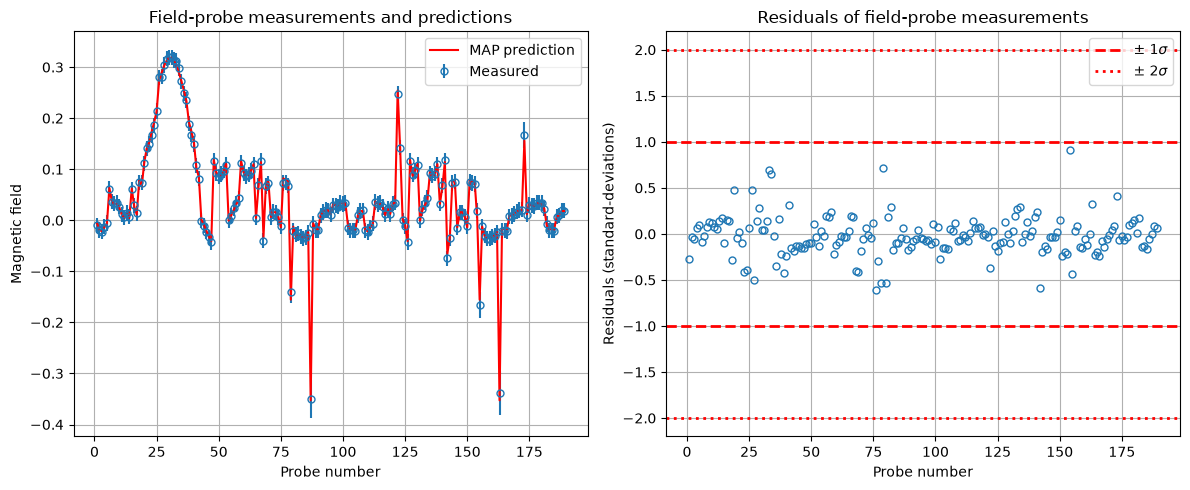

In [95]:
import matplotlib.pyplot as plt
from numpy import arange

probe_number = arange(probe_timeslice.measurements.size) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    probe_number,
    probe_timeslice.measurements,
    yerr=probe_timeslice.uncertainties,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
    label="Measured",
)
ax1.plot(
    probe_number,
    map_predictions["field_probes"],
    label="MAP prediction",
    c="red"
)
ax1.set_xlabel("Probe number")
ax1.set_ylabel("Magnetic field")
ax1.set_title("Field-probe measurements and predictions")
ax1.grid()
ax1.legend()

residuals = (probe_timeslice.measurements - map_predictions["field_probes"]) / probe_timeslice.uncertainties
ax2.plot(
    probe_number,
    residuals,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
)
ax2.axhline(1, lw=2, ls="--", c="red", label=r"$\pm$ 1$\sigma$")
ax2.axhline(-1, lw=2, ls="--", c="red")
ax2.axhline(2, lw=2, ls="dotted", c="red", label=r"$\pm$ 2$\sigma$")
ax2.axhline(-2, lw=2, ls="dotted", c="red")
ax2.set_xlabel("Probe number")
ax2.set_ylabel("Residuals (standard-deviations)")
ax2.set_title("Residuals of field-probe measurements")
ax2.grid()
ax2.legend()

fig.tight_layout()
plt.show()

Check the agreement of the flux-loops

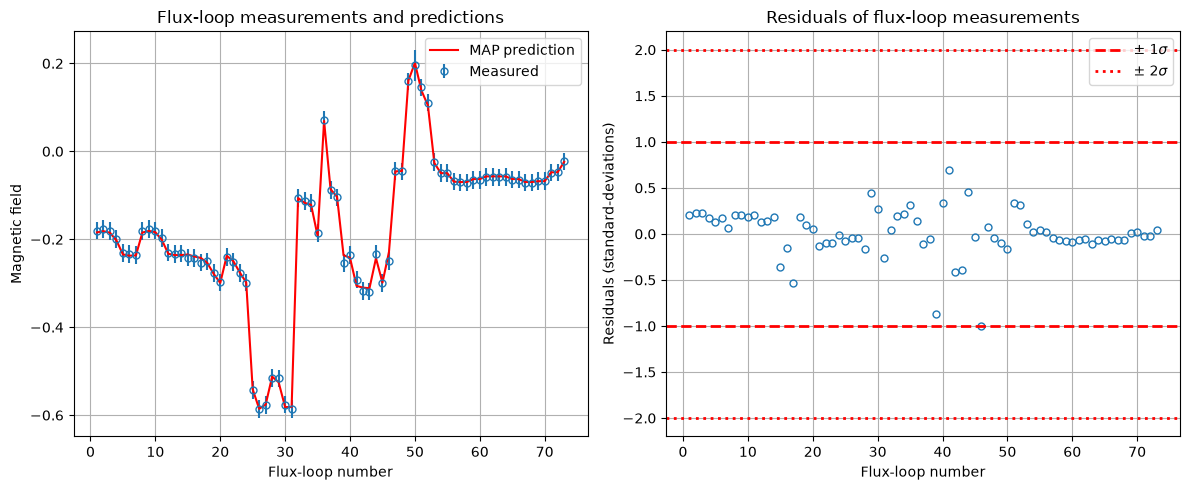

In [96]:
import matplotlib.pyplot as plt
from numpy import arange

probe_number = arange(fluxloop_timeslice.measurements.size) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    probe_number,
    fluxloop_timeslice.measurements,
    yerr=fluxloop_timeslice.uncertainties,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
    label="Measured",
)
ax1.plot(
    probe_number,
    map_predictions["fluxloops"],
    label="MAP prediction",
    c="red"
)
ax1.set_xlabel("Flux-loop number")
ax1.set_ylabel("Magnetic field")
ax1.set_title("Flux-loop measurements and predictions")
ax1.grid()
ax1.legend()

residuals = (fluxloop_timeslice.measurements - map_predictions["fluxloops"]) / fluxloop_timeslice.uncertainties
ax2.plot(
    probe_number,
    residuals,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
)
ax2.axhline(1, lw=2, ls="--", c="red", label=r"$\pm$ 1$\sigma$")
ax2.axhline(-1, lw=2, ls="--", c="red")
ax2.axhline(2, lw=2, ls="dotted", c="red", label=r"$\pm$ 2$\sigma$")
ax2.axhline(-2, lw=2, ls="dotted", c="red")
ax2.set_xlabel("Flux-loop number")
ax2.set_ylabel("Residuals (standard-deviations)")
ax2.set_title("Residuals of flux-loop measurements")
ax2.grid()
ax2.legend()

fig.tight_layout()
plt.show()

Check the agreement with the pressure data:

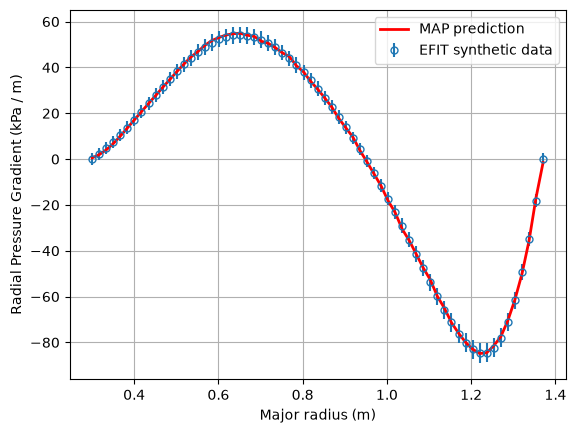

In [81]:
plt.errorbar(
    profile_radius,
    grad_p * 1e-3,
    yerr=grad_p_sigma * 1e-3,
    marker="o",
    markerfacecolor="none",
    markersize=5,
    ls="none",
    label="EFIT synthetic data"
)

plt.plot(
    profile_radius, map_predictions["radial_pressure_gradient"] * 1e-3,
    lw=2, c="red", label="MAP prediction"
)
plt.xlabel("Major radius (m)")
plt.ylabel("Radial Pressure Gradient (kPa / m)")
plt.legend()
plt.grid()
plt.show()

### Plot the inferred toroidal current density $J_\phi$

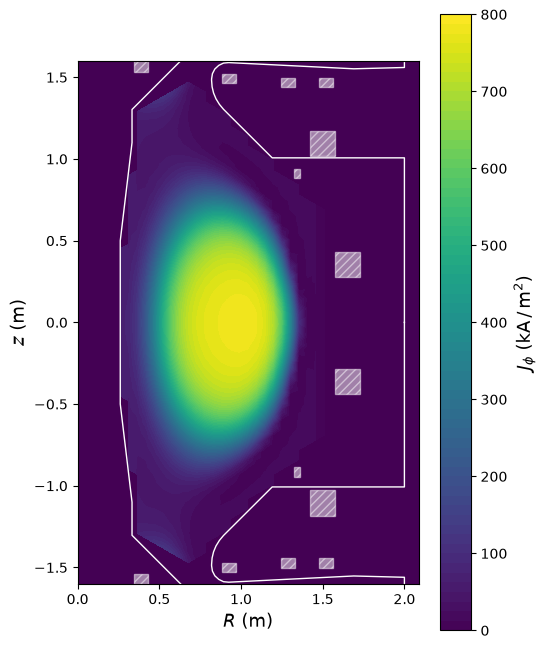

In [82]:
from tokamesh.tokamaks import mastu_boundary
from mastora.diagnostics.magnetics.coils.cases import draw_cases
from numpy import exp, linspace

map_param_dict = PlasmaState.split_parameters(map_estimate_params)
J_values = exp(map_param_dict["ln_J"])
color_levels = linspace(0.0, 8e2, 65)


fig = plt.figure(figsize=(5.5, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_facecolor(plt.get_cmap("viridis")(0.0))
contours = ax.tricontourf(
    basis_info.R,
    basis_info.z,
    basis_info.triangles,
    J_values * 1e-3,
    levels=color_levels,
    cmap="viridis",
)

cbar = fig.colorbar(contours, ax=ax)
cbar.set_label(r"$J_{\phi}$ $\mathrm{(kA \,/\, m^2)}$", fontsize=13)
cbar.set_ticks(linspace(0, 8e2, 9))

ax.plot(*mastu_boundary(), lw=1, color="white")
draw_cases(ax, fill_color="white")
ax.set_aspect("equal")
ax.set_xlim([0, None])

ax.set_ylim([-1.6, 1.6])
ax.set_xlabel(r"$R$ (m)", fontsize=13)
ax.set_ylabel(r"$z$ (m)", fontsize=13)
plt.show()

### Calculate $\psi(R, z)$

Build a mesh on which to evaluate $\psi$:

In [83]:
from numpy import linspace, meshgrid
n = 64
R_axis = linspace(0.0, 2.1, n)
z_axis = linspace(-2.2, 2.2, 2*n)
R_mesh, z_mesh = meshgrid(R_axis, z_axis, indexing='ij')

Get the $\psi$ contribution from the PF coils:

In [84]:
pf_psi = mastu_coil_set.psi(currents=pf_data.measurements, R=R_mesh.flatten(), z=z_mesh.flatten())
pf_psi = pf_psi.reshape(R_mesh.shape)

Get the $\psi$ contribution from the plasma current and calcualte the total $\psi$:

In [85]:
from numpy import load
psi_data = load("hex_basis_psi_matrix.npz")

plasma_psi = psi_data["hex_basis_psi_matrix"] @ J_values
plasma_psi = plasma_psi.reshape(R_mesh.shape)

psi = pf_psi + plasma_psi

Use the `NormalisedPoloidalFlux` tool from `astora` to get $\psi_N$:

In [86]:
from astora.tools import NormalisedPoloidalFlux
psi = pf_psi + plasma_psi
PsiNorm = NormalisedPoloidalFlux(R=R_axis, z=z_axis, psi=psi, boundary=None)

Plot $\psi_N$ and the separatrix:

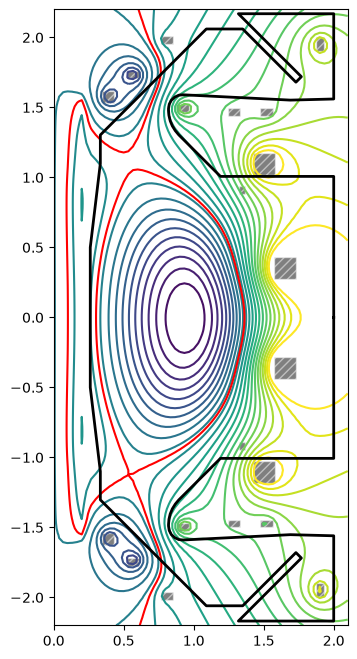

In [87]:
fig = plt.figure(figsize=(4.5, 8.0))
ax = fig.add_subplot(1, 1, 1)

PsiNorm.plot_equilibrium(axis=ax, flux_range=(0.0, 2.2))
ax.plot(*mastu_boundary(), lw=2, color="black")
draw_cases(ax, fill_color="black")
plt.show()

## Equilibrium condition check

Find the difference between the $J_\phi$ parameter values and the prediction of the equilibrium $J_\phi$ at each mesh vertex:

In [88]:
from midas import FieldRequest, Fields, Parameters

map_param_dict = PlasmaState.split_parameters(map_estimate_params)
J_values = exp(map_param_dict["ln_J"])
basis_coordinates = {"R": hex_basis.R_basis, "z": hex_basis.z_basis,}


PlasmaState.theta = map_estimate_params.copy()
_, field_values = PlasmaState.get_values(
    parameters=Parameters(),
    fields=Fields(
        FieldRequest(name="FF_prime", coordinates=basis_coordinates),
        FieldRequest(name="p_prime", coordinates=basis_coordinates)
    )
)

J_eq = equilibrium_current_prior.equilibrium_currents(
    p_prime=field_values["p_prime"],
    FF_prime=field_values["FF_prime"]
)

J_diff = J_values - J_eq

eq_stats = f"""
[ Equilibrium condition statistics ]
        Maximum absolute current difference: {abs(J_diff).max():.2f} (A / m^2)
           Mean absolute current difference: {abs(J_diff).mean():.2f} (A / m^2)
Mean absolute percentage current difference: {abs((J_values / J_eq - 1)).mean() * 100:.2f} (%)
"""
print(eq_stats)


[ Equilibrium condition statistics ]
        Maximum absolute current difference: 572.18 (A / m^2)
           Mean absolute current difference: 7.45 (A / m^2)
Mean absolute percentage current difference: 0.23 (%)



Now plot the current density differences on the mesh:

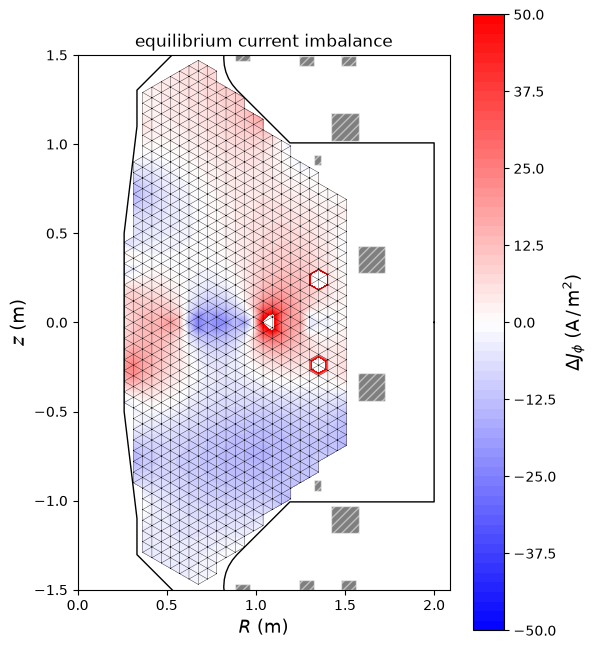

In [89]:
fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(1, 1, 1)

J_limit = 50.0
contours = ax.tricontourf(
    basis_info.R,
    basis_info.z,
    basis_info.triangles,
    J_diff,
    levels=linspace(-J_limit, J_limit, 65),
    cmap="bwr",
)

cbar = fig.colorbar(contours, ax=ax)
cbar.set_label(r"$\Delta J_{\phi}$ $\mathrm{(A \,/\, m^2)}$", fontsize=13)
cbar.set_ticks(linspace(-J_limit, J_limit, 9))

ax.triplot(basis_info.R, basis_info.z, basis_info.triangles, color="black", lw=0.25)
ax.plot(*mastu_boundary(), lw=1, color="black")
draw_cases(ax, fill_color="black")
ax.set_aspect("equal")
ax.set_xlim([0, None])
ax.set_ylim([-1.5, 1.5])
ax.set_xlabel(r"$R$ (m)", fontsize=13)
ax.set_ylabel(r"$z$ (m)", fontsize=13)
ax.set_title("equilibrium current imbalance")
plt.show()